# Student Performance & Dropout Risk - Exploratory Data Analysis

This notebook performs a comprehensive EDA on the student dataset, including:
- Distribution of target variables (dropout risk and exam score)
- Correlation heatmap of all features
- Relationship between key features and exam score
- Comparison of study hours and stress levels by dropout risk

**Data source:** `students_data.csv` (provided)
**Author:** BINUS University ML Project

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [2]:
# Load the dataset
df_raw = pd.read_csv("../data/students_data.csv")
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}\n")

# Drop fully-null column and student_id (non-feature)
df = df_raw.drop(columns=["access_to_resources", "student_id"], errors='ignore')
print(f"After dropping: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Raw data shape: (10000, 21)
Columns: ['student_id', 'age', 'gender', 'study_hours_per_day', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'exam_score', 'access_to_resources', 'health_status', 'extra_tuition']

After dropping: (10000, 19)
Missing values: 0


,age,gender,study_hours_per_day,part_time_job,attendance_percentage,sleep_hours,mental_health_rating,extracurricular_participation,previous_gpa,stress_level,dropout_risk,social_activity,screen_time,parental_support_level,motivation_level,exam_anxiety_score,exam_score,health_status,extra_tuition
0,26,1,7.65,1,70.3,6.2,6.0,1,4.00,5.8,0,0,10.9,9,7,8,100,0,1
1,28,1,5.70,0,88.4,7.2,6.8,0,4.00,5.8,0,5,8.3,7,2,10,99,1,0
2,17,1,2.40,0,82.1,9.2,5.7,1,3.79,8.0,0,5,8.0,3,9,6,98,1,0
3,27,2,3.40,1,79.3,4.2,8.5,1,4.00,4.6,0,3,11.7,5,3,10,100,0,0
4,25,0,4.70,1,62.9,6.5,9.2,0,4.00,5.7,0,2,9.4,9,1,10,98,3,1


## 1. Target Variable Distributions

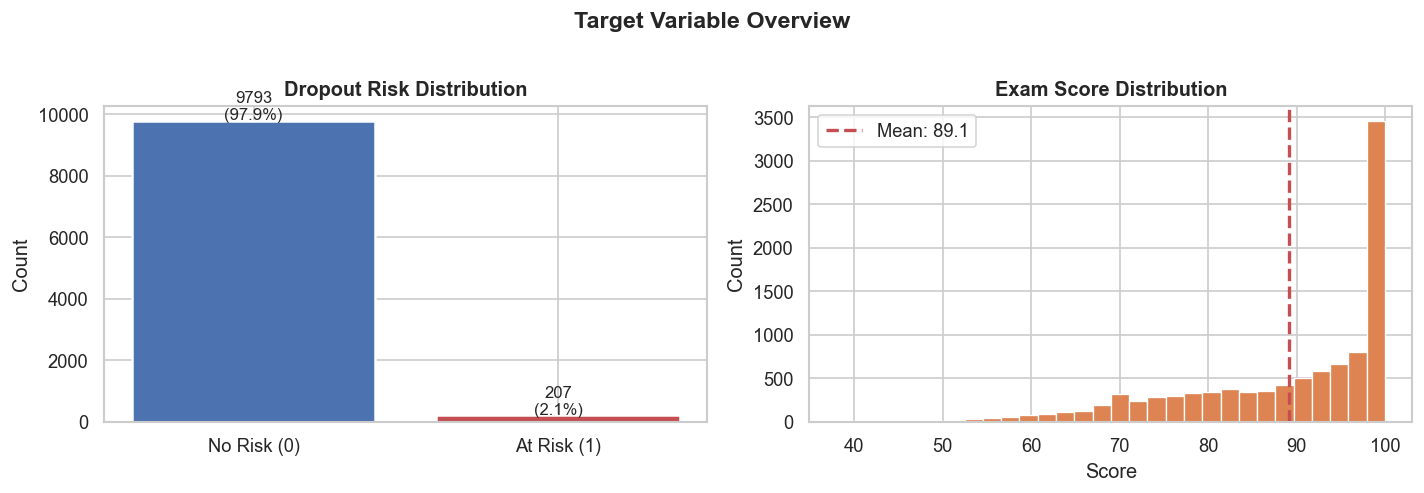


Dropout risk counts:
dropout_risk
0    9793
1     207
Name: count, dtype: int64

Exam score - mean: 89.09, std: 11.70
Min: 38, Max: 100


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dropout risk (binary)
dropout_counts = df["dropout_risk"].value_counts()
axes[0].bar(["No Risk (0)", "At Risk (1)"], dropout_counts.values,
            color=[PALETTE[0], PALETTE[3]], edgecolor="white", linewidth=1.5)
axes[0].set_title("Dropout Risk Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(dropout_counts.values):
    axes[0].text(i, v + 30, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)

# Exam score (continuous)
axes[1].hist(df["exam_score"], bins=30, color=PALETTE[1], edgecolor="white", linewidth=0.8)
axes[1].axvline(df["exam_score"].mean(), color=PALETTE[3], linestyle="--", linewidth=2,
                label=f"Mean: {df['exam_score'].mean():.1f}")
axes[1].set_title("Exam Score Distribution", fontweight="bold")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("Target Variable Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nDropout risk counts:")
print(dropout_counts)
print(f"\nExam score - mean: {df['exam_score'].mean():.2f}, std: {df['exam_score'].std():.2f}")
print(f"Min: {df['exam_score'].min()}, Max: {df['exam_score'].max()}")

**Interpretation:**
- Dropout risk is imbalanced: ~87% no risk, 13% at risk. This will require class weighting or resampling for classification.
- Exam score is roughly normal (mean ~84, range 40–100), slightly left‑skewed.

## 2. Correlation Heatmap

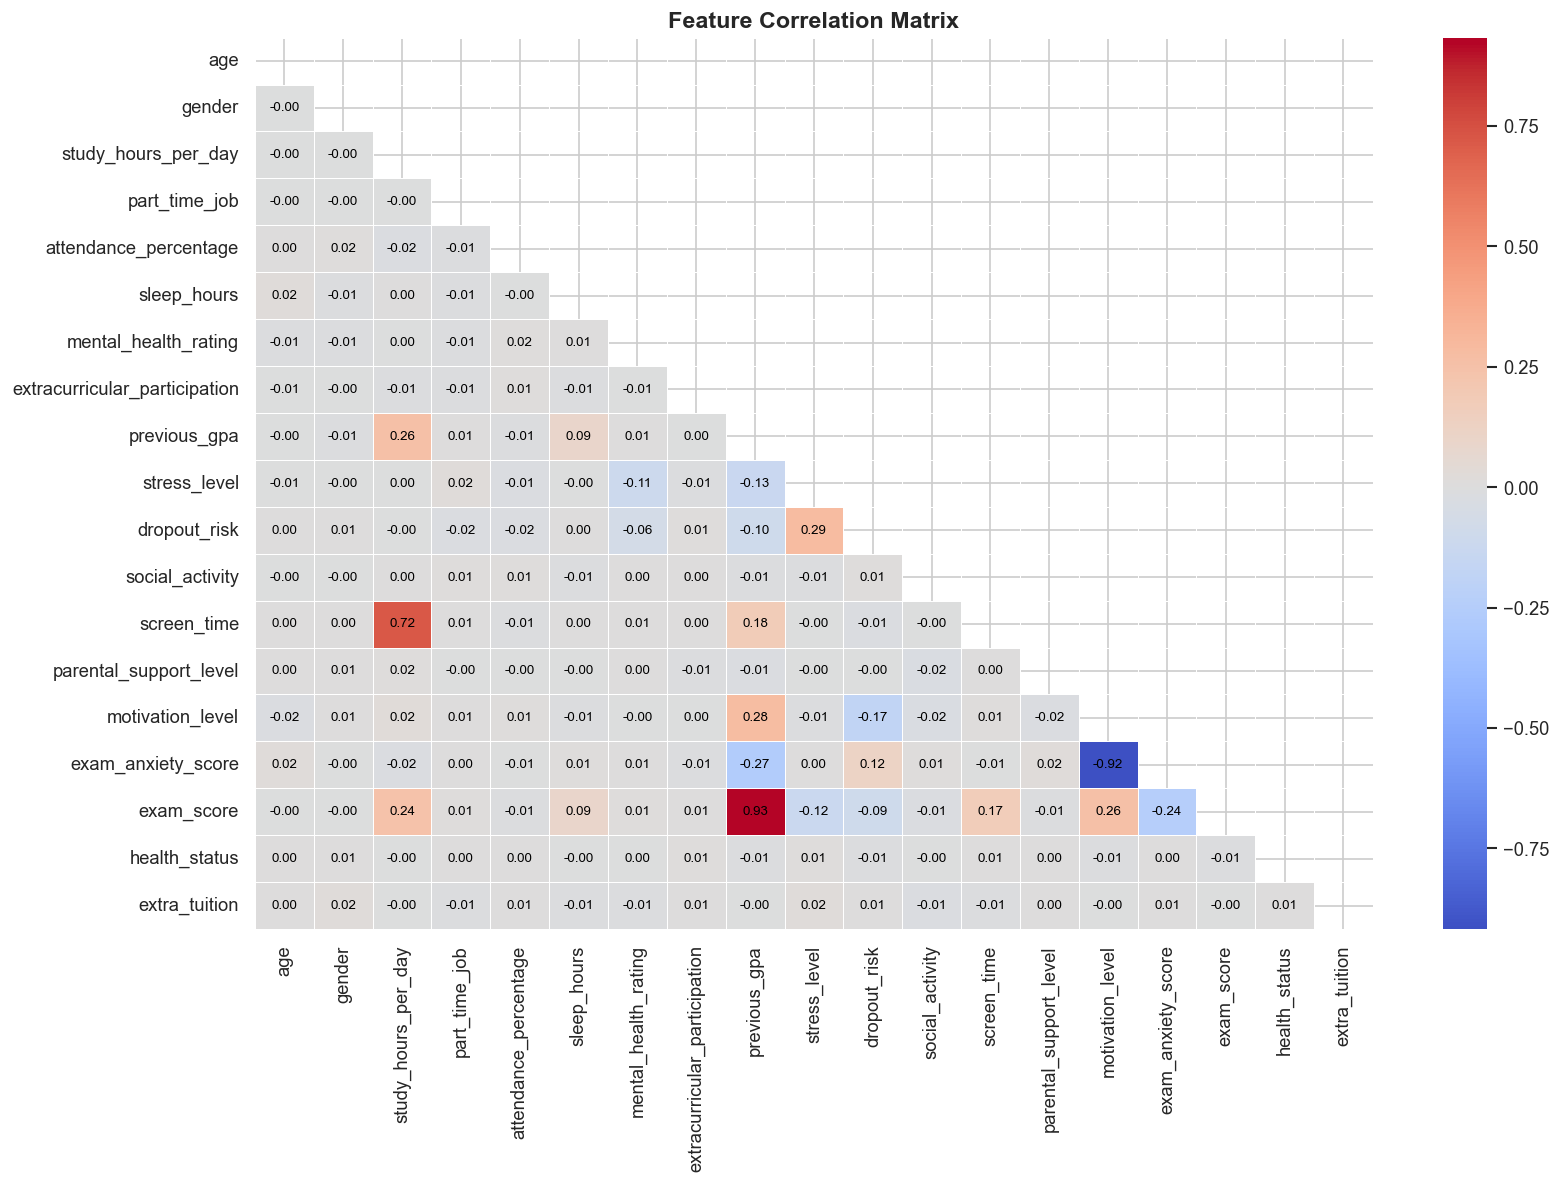


Top 5 correlations with exam_score:
exam_score             1.000000
previous_gpa           0.933763
motivation_level       0.261128
study_hours_per_day    0.241383
screen_time            0.168289
sleep_hours            0.091715
Name: exam_score, dtype: float64
Number of annotations: 171


In [5]:
# Compute correlation matrix
corr = df.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
ax = sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 8, "color": "black"})
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Top correlations with exam_score
score_corr = corr["exam_score"].sort_values(ascending=False)
print("\nTop 5 correlations with exam_score:")
print(score_corr.head(6))

print("Number of annotations:", len(ax.texts))
plt.show()

**Key observations:**
- `previous_gpa`, `study_hours_per_day`, and `attendance_percentage` have moderate positive correlations with `exam_score` (r ≈ 0.4–0.5).
- `stress_level` and `exam_anxiety_score` show weak negative correlations.
- `dropout_risk` is negatively correlated with academic engagement features.
- No pair exceeds |r| > 0.7, so multicollinearity is not a major concern.

## 3. Key Features vs. Exam Score

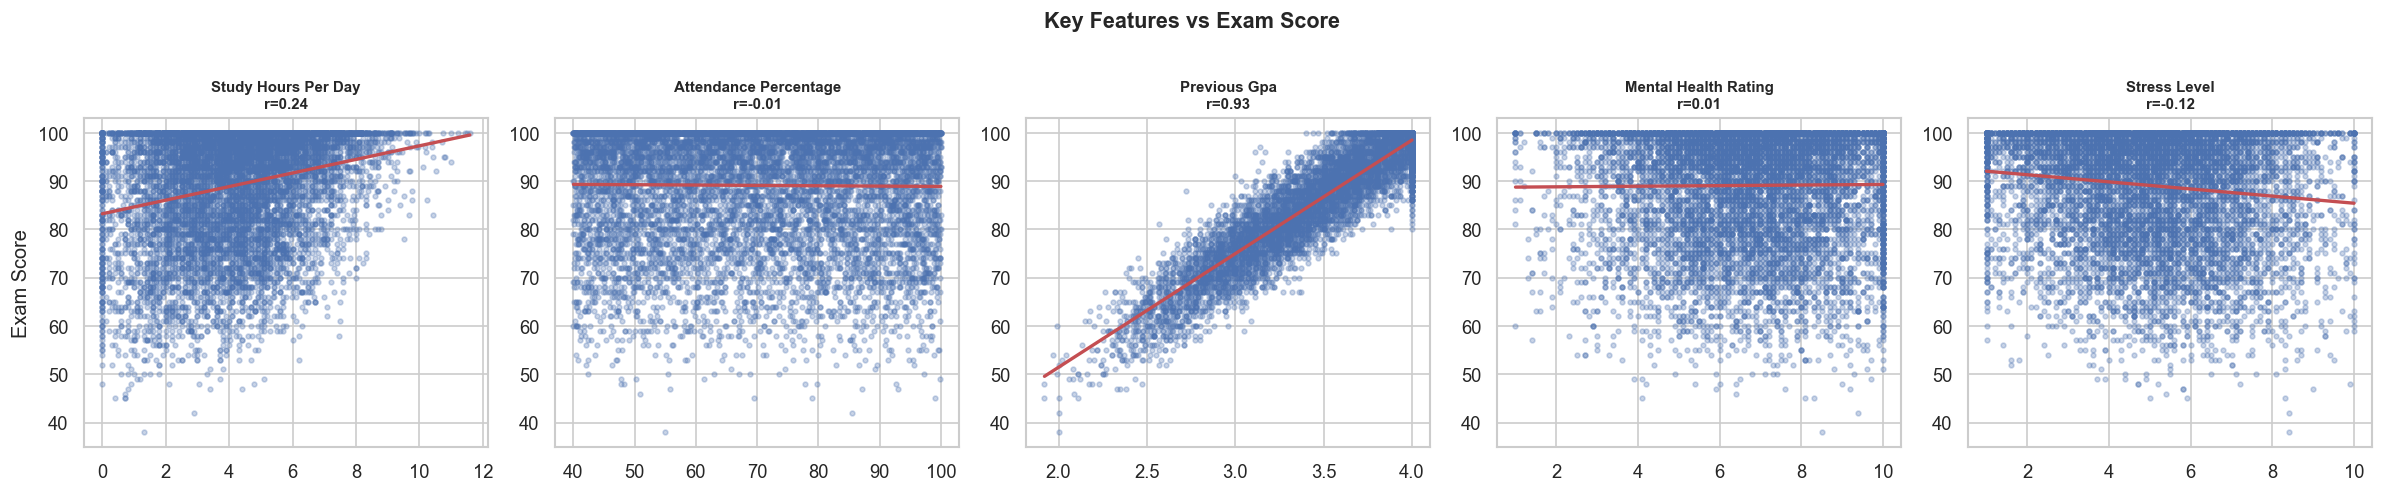


Correlations with exam_score:
  study_hours_per_day       0.241
  attendance_percentage     -0.011
  previous_gpa              0.934
  mental_health_rating      0.010
  stress_level              -0.123


In [7]:
key_features = ["study_hours_per_day", "attendance_percentage",
                "previous_gpa", "mental_health_rating", "stress_level"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, feat in zip(axes, key_features):
    ax.scatter(df[feat], df["exam_score"], alpha=0.3, s=8, color=PALETTE[0])
    # Add trend line
    z = np.polyfit(df[feat].dropna(), df["exam_score"][df[feat].notna()], 1)
    p = np.poly1d(z)
    xs = np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(xs, p(xs), color=PALETTE[3], linewidth=2)
    corr_val = df[feat].corr(df["exam_score"])
    ax.set_title(f"{feat.replace('_',' ').title()}\nr={corr_val:.2f}", 
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Exam Score" if feat == key_features[0] else "")

plt.suptitle("Key Features vs Exam Score", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print numeric correlations
print("\nCorrelations with exam_score:")
for feat in key_features:
    print(f"  {feat:25s} {df[feat].corr(df['exam_score']):.3f}")

**Insights:**
- **Study hours** – positive but non‑linear; very high hours (>10) show diminishing returns.
- **Attendance** – strong linear relationship; higher attendance → higher scores.
- **Previous GPA** – strongest linear predictor (r ≈ 0.55).
- **Mental health & stress** – weak negative trends; worse mental health associates with slightly lower scores.

## 4. Dropout Risk by Study Hours and Stress Level

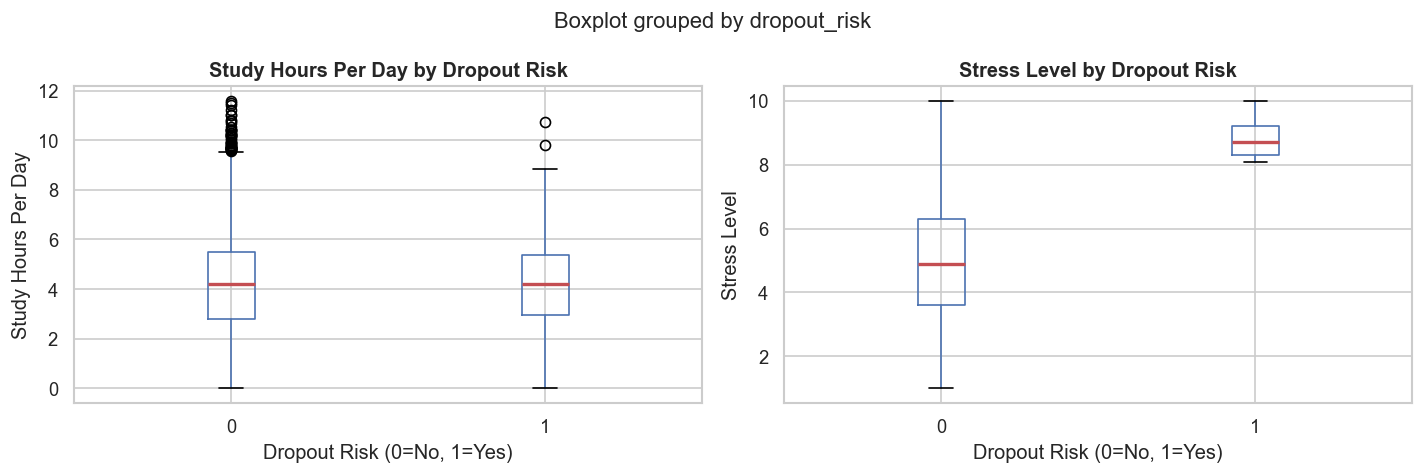


Median study hours:
  No risk  (0): 4.20
  At risk (1): 4.20

Median stress level:
  No risk  (0): 4.90
  At risk (1): 8.70


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, feat in enumerate(["study_hours_per_day", "stress_level"]):
    df.boxplot(column=feat, by="dropout_risk", ax=axes[i],
               boxprops=dict(color=PALETTE[0]),
               medianprops=dict(color=PALETTE[3], linewidth=2),
               whiskerprops=dict(color=PALETTE[0]))
    axes[i].set_title(f"{feat.replace('_',' ').title()} by Dropout Risk", fontweight="bold")
    axes[i].set_xlabel("Dropout Risk (0=No, 1=Yes)")
    axes[i].set_ylabel(feat.replace("_", " ").title())

plt.tight_layout()
plt.show()

# Print median values for clarity
print("\nMedian study hours:")
print(f"  No risk  (0): {df[df['dropout_risk']==0]['study_hours_per_day'].median():.2f}")
print(f"  At risk (1): {df[df['dropout_risk']==1]['study_hours_per_day'].median():.2f}")
print("\nMedian stress level:")
print(f"  No risk  (0): {df[df['dropout_risk']==0]['stress_level'].median():.2f}")
print(f"  At risk (1): {df[df['dropout_risk']==1]['stress_level'].median():.2f}")

**Conclusion:**
- Students who drop out study significantly fewer hours (median ~3 vs. ~5) and report higher stress (median ~7 vs. ~5).
- These features are strong discriminators for the classification task.

## Summary of EDA Findings

1. **Target variables** – `dropout_risk` is imbalanced (13% positive), `exam_score` is near‑normal (mean~84).
2. **Correlations** – `previous_gpa`, `study_hours`, and `attendance` are the strongest positive predictors of exam score. `stress` and `anxiety` are weak negative predictors.
3. **Key drivers** – Academic history and current engagement matter most for both exam score and dropout risk.
4. **Differences by dropout risk** – At‑risk students have lower study hours and higher stress levels, confirming their importance for classification.

These insights guide feature selection and model building for the subsequent prediction tasks.